In [1]:
import sys
sys.path.append("../utils/py")
import miniramses as ram

In [2]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import miniramses as ram

# -----------------------------
# Matplotlib config
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 800
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

# -----------------------------
# Global settings
# -----------------------------
center = np.array([1, 1, 1])


# -----------------------------
# Utilities
# -----------------------------
def normalize_dir(path):
    """Normalize path safely."""
    return os.path.abspath(path)


def infer_isort(prefix):
    """Validate prefix."""
    if prefix is None:
        prefix = "hydro"

    prefix = prefix.lower()

    if prefix in ["hydro", "grav", "rt"]:
        return 0
    elif prefix == "peak":
        return 1
    else:
        raise ValueError(f"Unknown prefix: {prefix}")


def read_output(output_path, center=center):
    """
    Read RAMSES output from full directory path.

    Example:
        /home/.../mini-ramses/output_00004
    """
    output_path = normalize_dir(output_path)

    nout_dir = os.path.basename(output_path)
    base_path = os.path.dirname(output_path)

    if not nout_dir.startswith("output_"):
        raise ValueError(
            f"Expected path like '.../output_00004', got: {output_path}"
        )

    nout = nout_dir.split("_")[-1]
    print("I am reading nout: ", nout)

    candidate_prefixes = ["grav", "hydro", "rt", "peak"]
    last_err = None

    for prefix in candidate_prefixes:
        try:
            infer_isort(prefix)

            c = ram.rd_cell(nout, path=base_path, prefix=prefix, center=center)
            i = ram.rd_info(nout, path=base_path)

            print(f"[OK] {output_path} (prefix='{prefix}')")
            return c, i, prefix

        except Exception as err:
            last_err = err

    raise RuntimeError(
        f"Failed to read {output_path} with known prefixes.\nLast error: {last_err}"
    )


def amr_slice(c, cen, levels=None):
    """
    Select cells intersecting plane z = cen.
    """
    mask = np.abs(c.x[2] - cen) <= c.dx / 2

    if levels is not None:
        mask &= np.isin(c.level, levels)

    x = c.x[0][mask]
    y = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask


# -----------------------------
# Plot single output
# -----------------------------
def plot(output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Plot one output.

    Parameters
    ----------
    output_path : str
        Path to output directory
    cen : float
        z-slice center
    levels : list or None
        AMR levels to include
    field_index : int
        which component of c.g to plot
    """

    print("Reading:", output_path)

    c, i, prefix = read_output(output_path, center=center)

    print("Levels:", np.unique(c.level))
    x, y, dx, mask = amr_slice(c, cen, levels)

    val = c.g[field_index][mask]
    lev = c.level[mask]

    return ram.visu(x, y, dx, val, lev, **visu_kwargs)


# -----------------------------
# Compare two outputs
# -----------------------------
def compare(output_path, base_output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Compare two outputs (difference plot).
    """

    print("Target:", output_path)
    print("Base  :", base_output_path)

    c, _, _ = read_output(output_path, center=center)
    c_base, _, _ = read_output(base_output_path, center=center)

    x, y, dx, mask = amr_slice(c, cen, levels)

    diff = c.g[field_index] - c_base.g[field_index]
    val = diff[mask]
    lev = c.level[mask]

    out = ram.visu(x, y, dx, val, lev, **visu_kwargs)

    denom = c_base.g[field_index][mask]
    good = denom != 0

    if np.any(good):
        rel = val[good] / denom[good]
        print("mean relative error :", np.mean(rel))
        print("median relative error:", np.median(rel))
    else:
        print("Relative error undefined (denominator zero everywhere)")

    return out

In [3]:
#nout =  '3'  # fmm (7,8) ! pre-direct-multipole expansion
#nout =  '4'  # multgrid  (7,8)
#nout =  '5'  # multigrid (8,8)
#nout =  '6'  # fmm (8,8)
#nout =  '23'  # fmm (7,8,9) ! pre-direct-multipole expansion
#nout =  '24'  # multgrid  (7,8,9)

In [4]:
import os
import matplotlib.pyplot as plt
import imageio
from tqdm import tqdm

base_dir = "/home/jl4415/mini-ramses/halo_test/halo_mg"
fig_dir = os.path.join(base_dir, "fig")

# make directory if it doesn't exist
os.makedirs(fig_dir, exist_ok=True)

# --- Generate and save plots with progress bar ---
for i in tqdm(range(2, 20), desc="Generating plots"):
    out_str = f"{i:05d}"
    out_path = os.path.join(base_dir, f"output_{out_str}")
    
    try:
        fig, ax = plot(
            out_path,
            cen=600.0,
            cmap="cividis",
            grid=True,
            return_fig=True
        )
        ax.set_title(f"Output {out_str}")
    except TypeError:
        plt.figure()
        plot(
            out_path,
            cen=600.0,
            cmap="cividis",
            grid=True
        )
        plt.title(f"Output {out_str}")
        fig = plt.gcf()
    
    save_path = os.path.join(fig_dir, f"output_{out_str}.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

# --- Create GIF with progress bar ---
images = []
for i in tqdm(range(2, 20), desc="Building GIF"):
    out_str = f"{i:05d}"
    img_path = os.path.join(fig_dir, f"output_{out_str}.png")
    
    if os.path.exists(img_path):
        images.append(imageio.imread(img_path))

gif_path = os.path.join(fig_dir, "animation.gif")
imageio.mimsave(gif_path, images, duration=0.5)

print(f"Saved GIF to: {gif_path}")

Generating plots:   0%|          | 0/18 [00:00<?, ?it/s]

Reading: /home/jl4415/mini-ramses/halo_test/halo_mg/output_00002
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0507913006738704
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1631232 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_mg/output_00002 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
Reading: /home/jl4415/mini-ramses/halo_test/halo_mg/output_00002
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0507913006738704
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1631232 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_mg/output_00002 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
subset value range: -110675.875 -11421.998046875
image range: -110632.3671875 -11425.4140625
spatial box: [300.0, 900.0, 300.0, 900.0]


Generating plots:   6%|▌         | 1/18 [00:06<01:55,  6.77s/it]

Reading: /home/jl4415/mini-ramses/halo_test/halo_mg/output_00003
I am reading nout:  00003
ncpu=1 ndim=3 nlevelmax=13
Time= 0.101366574612855
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1621138 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_mg/output_00003 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
Reading: /home/jl4415/mini-ramses/halo_test/halo_mg/output_00003
I am reading nout:  00003
ncpu=1 ndim=3 nlevelmax=13
Time= 0.101366574612855
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1621138 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_mg/output_00003 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
subset value range: -105773.9453125 -11422.798828125
image range: -105773.9453125 -11426.203125
spatial box: [300.0, 900.0, 300.0, 900.0]


Generating plots:  11%|█         | 2/18 [00:13<01:47,  6.71s/it]

...

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

In [5]:
import os
import matplotlib.pyplot as plt
import imageio
from tqdm import tqdm

base_dir = "/home/jl4415/mini-ramses/halo_test/halo_fmm"
fig_dir = os.path.join(base_dir, "fig")

# make directory if it doesn't exist
os.makedirs(fig_dir, exist_ok=True)

# --- Generate and save plots with progress bar ---
for i in tqdm(range(2, 20), desc="Generating plots"):
    out_str = f"{i:05d}"
    out_path = os.path.join(base_dir, f"output_{out_str}")
    
    try:
        fig, ax = plot(
            out_path,
            cen=600.0,
            cmap="cividis",
            grid=True,
            return_fig=True
        )
        ax.set_title(f"Output {out_str}")
    except TypeError:
        plt.figure()
        plot(
            out_path,
            cen=600.0,
            cmap="cividis",
            grid=True
        )
        plt.title(f"Output {out_str}")
        fig = plt.gcf()
    
    save_path = os.path.join(fig_dir, f"output_{out_str}.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

# --- Create GIF with progress bar ---
images = []
for i in tqdm(range(2, 20), desc="Building GIF"):
    out_str = f"{i:05d}"
    img_path = os.path.join(fig_dir, f"output_{out_str}.png")
    
    if os.path.exists(img_path):
        images.append(imageio.imread(img_path))

gif_path = os.path.join(fig_dir, "animation.gif")
imageio.mimsave(gif_path, images, duration=0.5)

print(f"Saved GIF to: {gif_path}")

Generating plots:   0%|          | 0/18 [00:00<?, ?it/s]

Reading: /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00002
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0508226812653299
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1634557 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00002 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
Reading: /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00002
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=13
Time= 0.0508226812653299
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1634557 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00002 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
subset value range: -109982.6328125 -11447.5283203125
image range: -109949.7890625 -11448.224609375
spatial box: [300.0, 900.0, 300.0, 900.0]


Generating plots:   6%|▌         | 1/18 [00:06<01:56,  6.85s/it]

Reading: /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00003
I am reading nout:  00003
ncpu=1 ndim=3 nlevelmax=13
Time= 0.101506806430136
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1625030 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00003 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
Reading: /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00003
I am reading nout:  00003
ncpu=1 ndim=3 nlevelmax=13
Time= 0.101506806430136
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1625030 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_fmm/output_00003 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
subset value range: -104941.75 -11446.1748046875
image range: -104937.078125 -11446.8642578125
spatial box: [300.0, 900.0, 300.0, 900.0]


Generating plots:  11%|█         | 2/18 [00:12<01:41,  6.32s/it]

...

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

<Figure size 4800x3200 with 0 Axes>

Reading: /home/jl4415/mini-ramses/halo_test/halo_mg/output_00019
I am reading nout:  00019
ncpu=1 ndim=3 nlevelmax=13
Time= 0.901096677371373
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1589491 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/halo_test/halo_mg/output_00019 (prefix='grav')
Levels: [ 6  7  8  9 10 11]
subset value range: -101271.2265625 -11452.388671875
image range: -101269.296875 -11455.47265625
spatial box: [300.0, 900.0, 300.0, 900.0]


(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x14a27c74a6d0>)

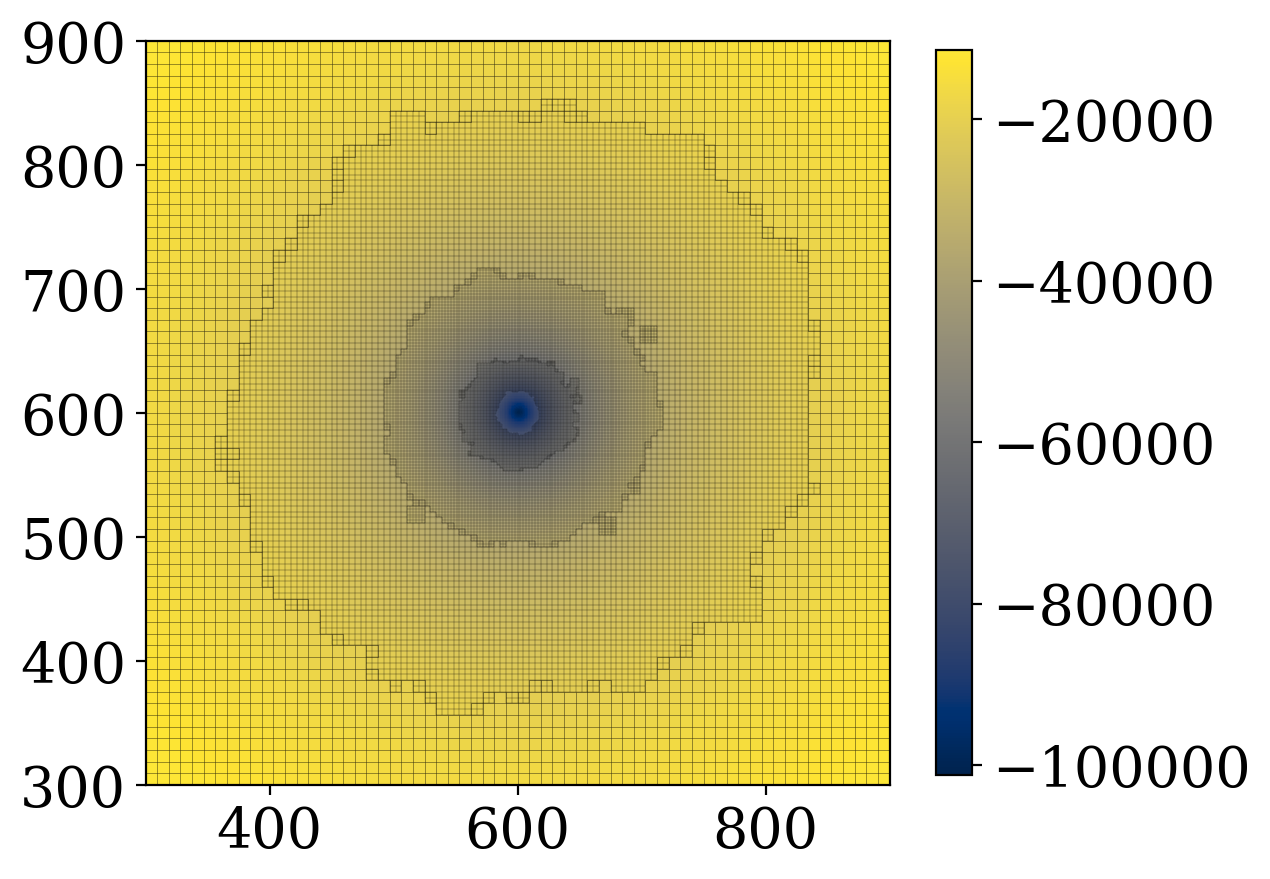

In [8]:
out1 = "/home/jl4415/mini-ramses/halo_test/halo_mg/output_00019"
plot(
    out1,
    cen=600.0,
    cmap="cividis",
    grid=True
)

In [7]:
import os
import imageio
import numpy as np
from PIL import Image, ImageDraw, ImageFont

base_dir = "/home/jl4415/mini-ramses/halo_test"

mg_gif = os.path.join(base_dir, "halo_mg", "fig", "animation.gif")
fmm_gif = os.path.join(base_dir, "halo_fmm", "fig", "animation.gif")

out_gif = os.path.join(base_dir, "comparison.gif")

# read gifs
mg_reader = imageio.get_reader(mg_gif)
fmm_reader = imageio.get_reader(fmm_gif)

n_frames = min(mg_reader.get_length(), fmm_reader.get_length())

frames = []

# try font
try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 60)
except:
    font = ImageFont.load_default()

for i in range(n_frames):
    mg_frame = Image.fromarray(mg_reader.get_data(i))
    fmm_frame = Image.fromarray(fmm_reader.get_data(i))
    
    # match heights
    if mg_frame.size[1] != fmm_frame.size[1]:
        fmm_frame = fmm_frame.resize(
            (int(fmm_frame.size[0] * mg_frame.size[1] / fmm_frame.size[1]), mg_frame.size[1])
        )
    
    total_width = mg_frame.size[0] + fmm_frame.size[0]
    max_height = mg_frame.size[1]
    
    # add space on top for titles
    combined = Image.new("RGB", (total_width, max_height + 60), (255, 255, 255))
    
    combined.paste(mg_frame, (0, 60))
    combined.paste(fmm_frame, (mg_frame.size[0], 60))
    
    draw = ImageDraw.Draw(combined)
    
    # titles
    draw.text((mg_frame.size[0] // 2 - 40, 10), "MG", fill="black", font=font)
    draw.text((mg_frame.size[0] + fmm_frame.size[0] // 2 - 50, 10), "FMM", fill="black", font=font)
    
    frames.append(np.array(combined))

# save gif
imageio.mimsave(out_gif, frames, duration=0.5)

print(f"Saved combined GIF to: {out_gif}")

Saved combined GIF to: /home/jl4415/mini-ramses/halo_test/comparison.gif


Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
subset value range: -3277.7578125 58.9609375
image range: -3277.7578125 39.625
spatial box: [356.25, 834.375, 365.625, 834.375]
mean relative error: 0.004017512853322425
median relative error: 0.0037571818978789397


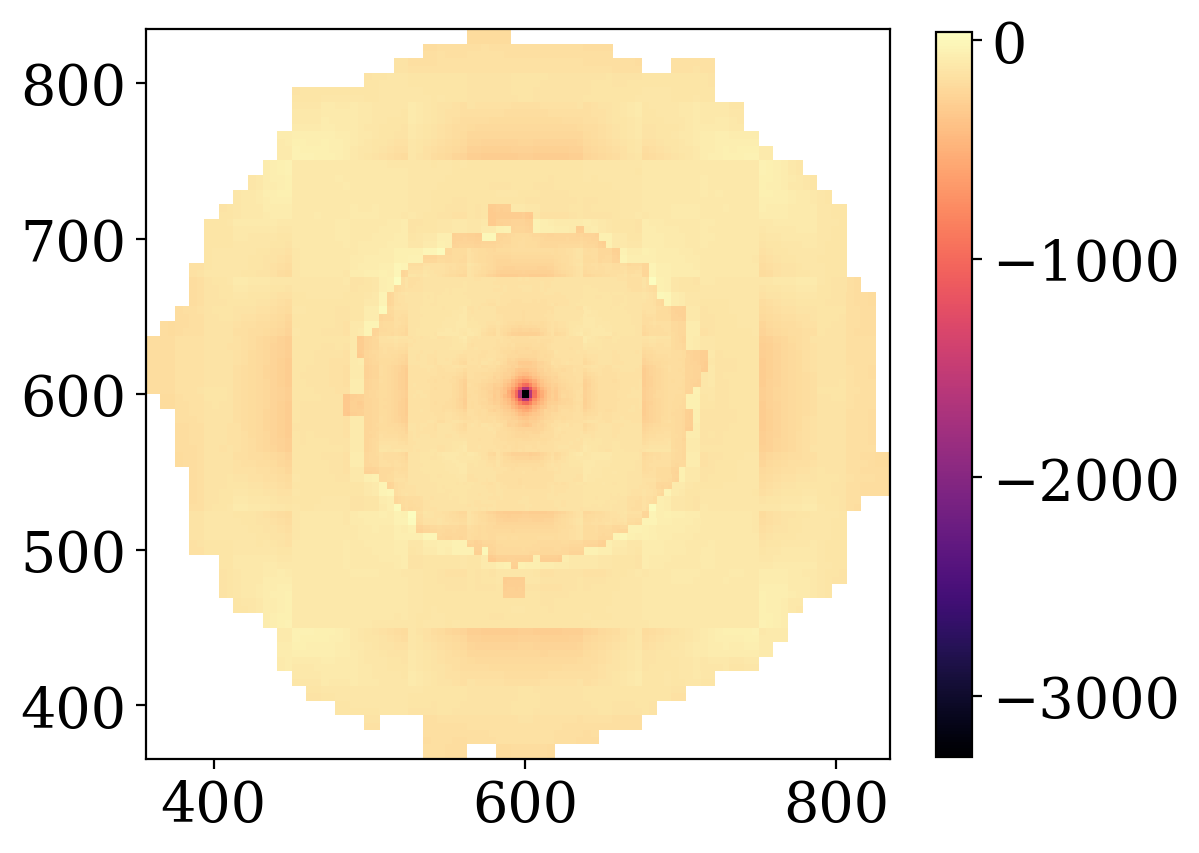

In [5]:
compare(24, 23, 600, levels=[7,8], grid=False)
plt.savefig("./fig/lev78.png")
#mk_image // project

Reading output 24 and base 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
subset value range: -3277.7578125 58.9609375
image range: -3277.7578125 39.625
spatial box: [300.0, 900.0, 300.0, 900.0]
mean relative error: 0.003992840508452441
median relative error: 0.0037402271830726244


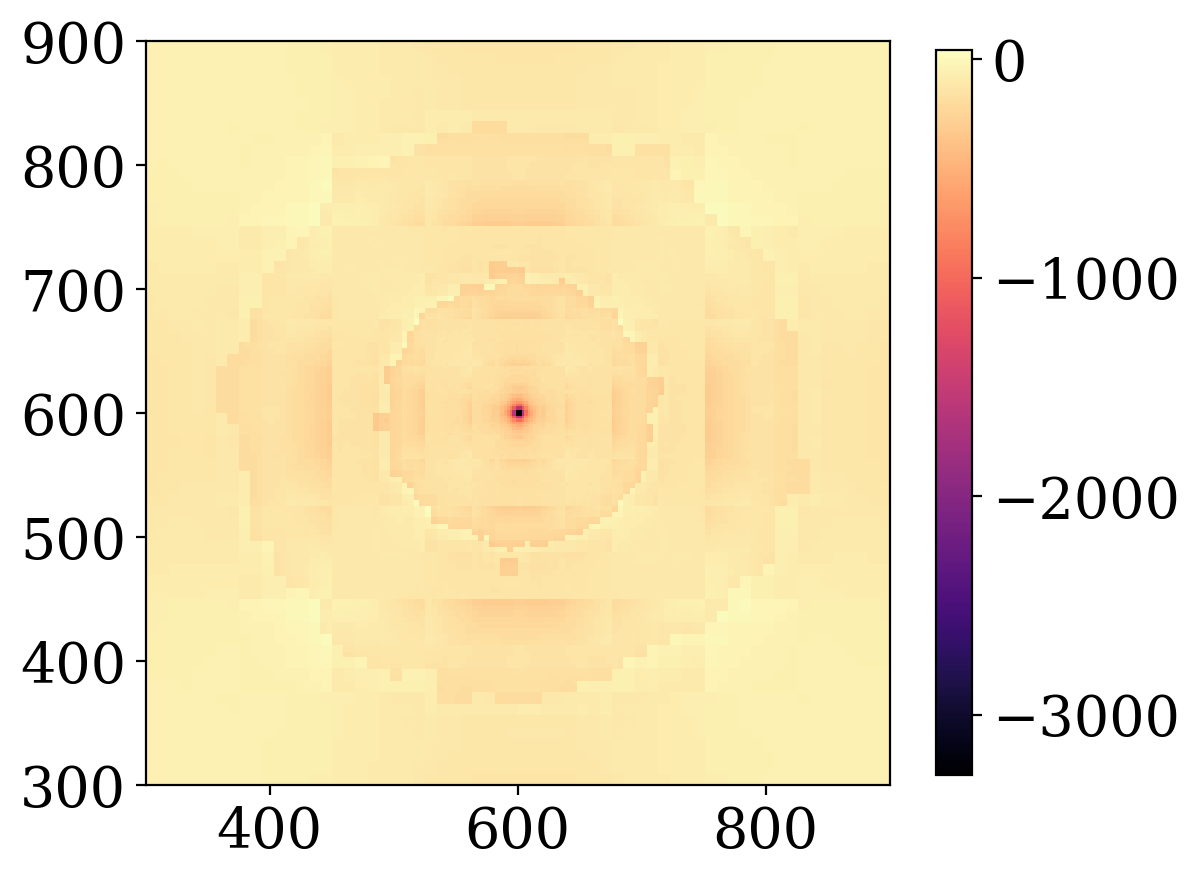

In [6]:
c = compare(24, 23, 600, grid=False, levels=[6,7,8])
plt.savefig("./fig/lev678.png")
#mk_image // project

Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
subset value range: -130217.2109375 -37048.78125
image range: -130217.2109375 -37048.78125
spatial box: [300, 900, 300, 900]
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 leaf cells
Extracting leaf cells...
Available levels: [6 7 8]
subset value range: -44965.15234375 -22240.92578125
image range: -44965.15234375 -22240.92578125
spatial box: [300, 900, 300, 900]
Reading output 23
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 1059143 le

(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x14e633618af0>)

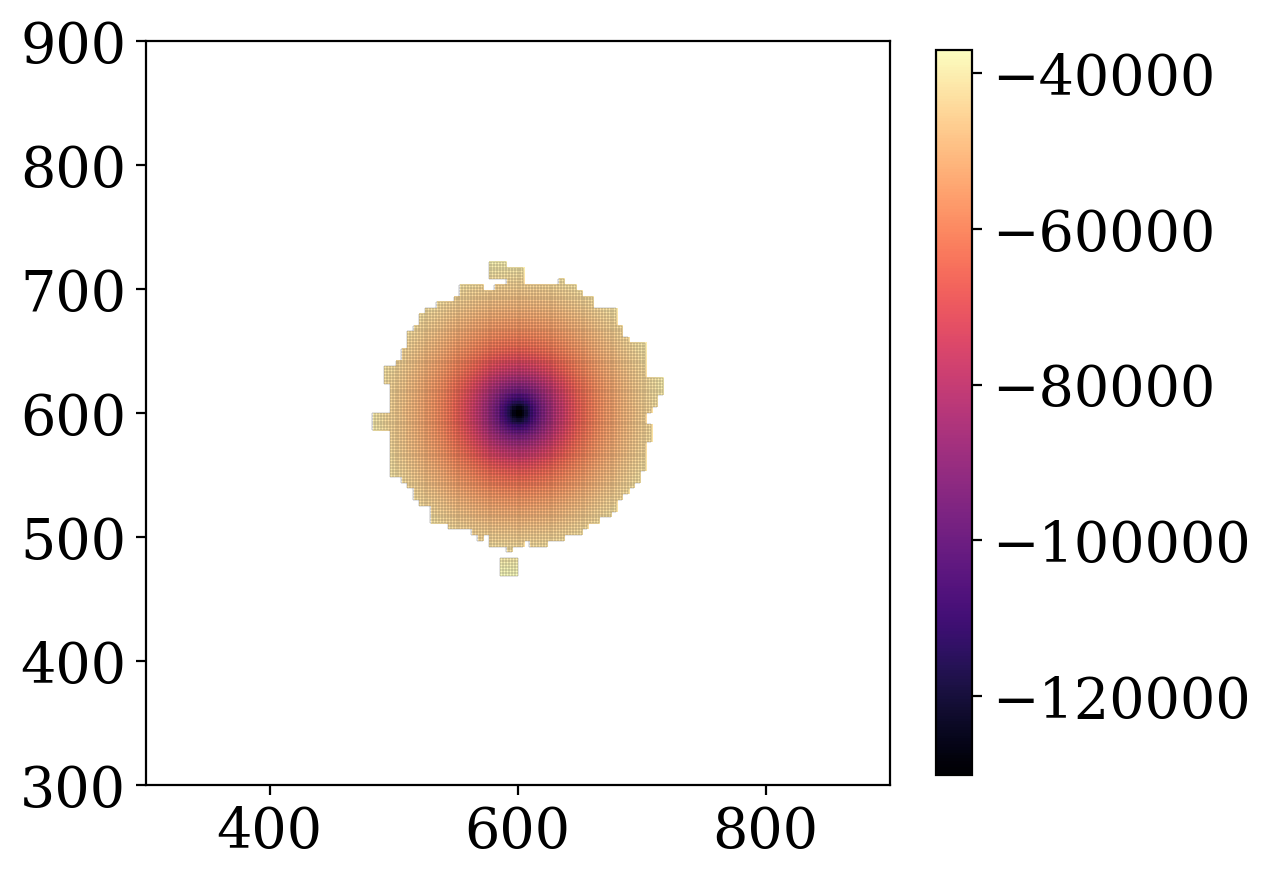

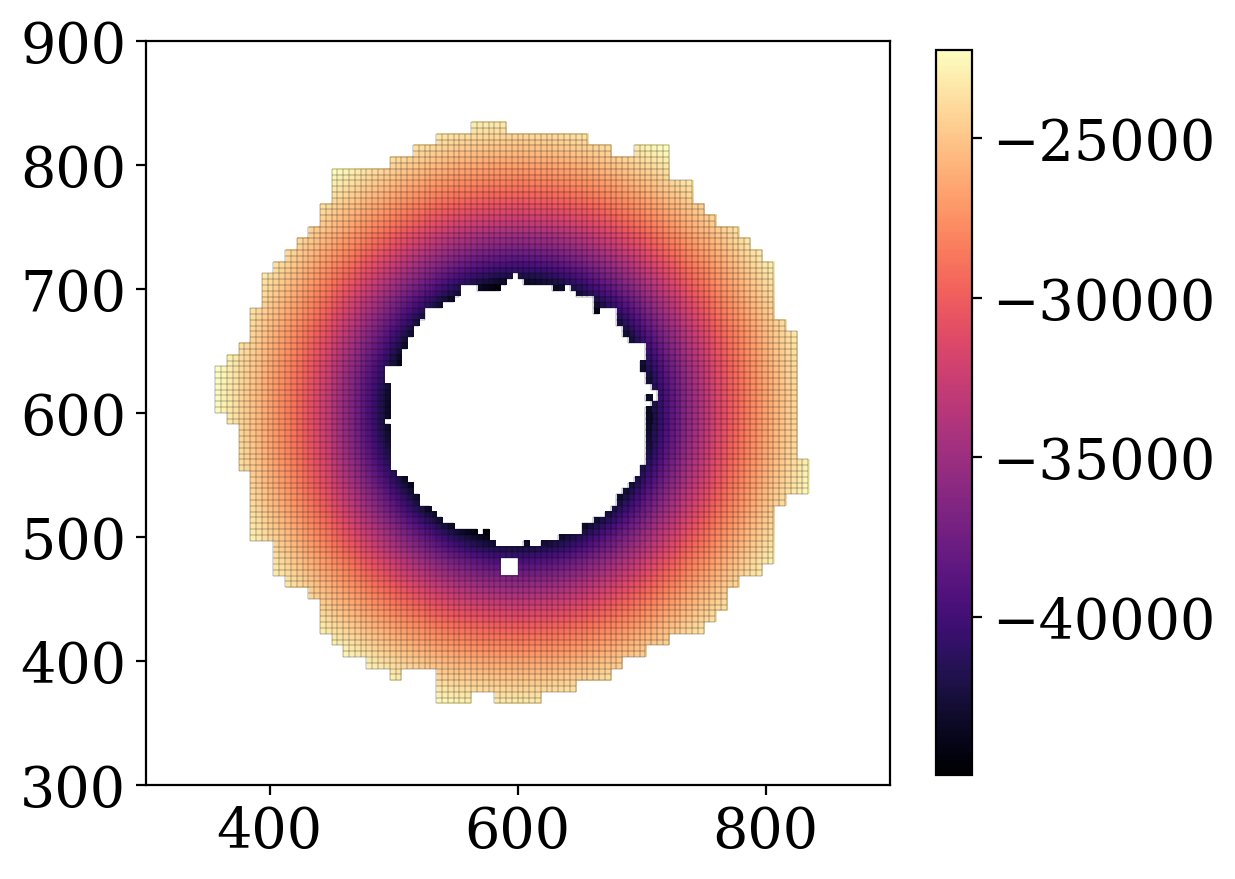

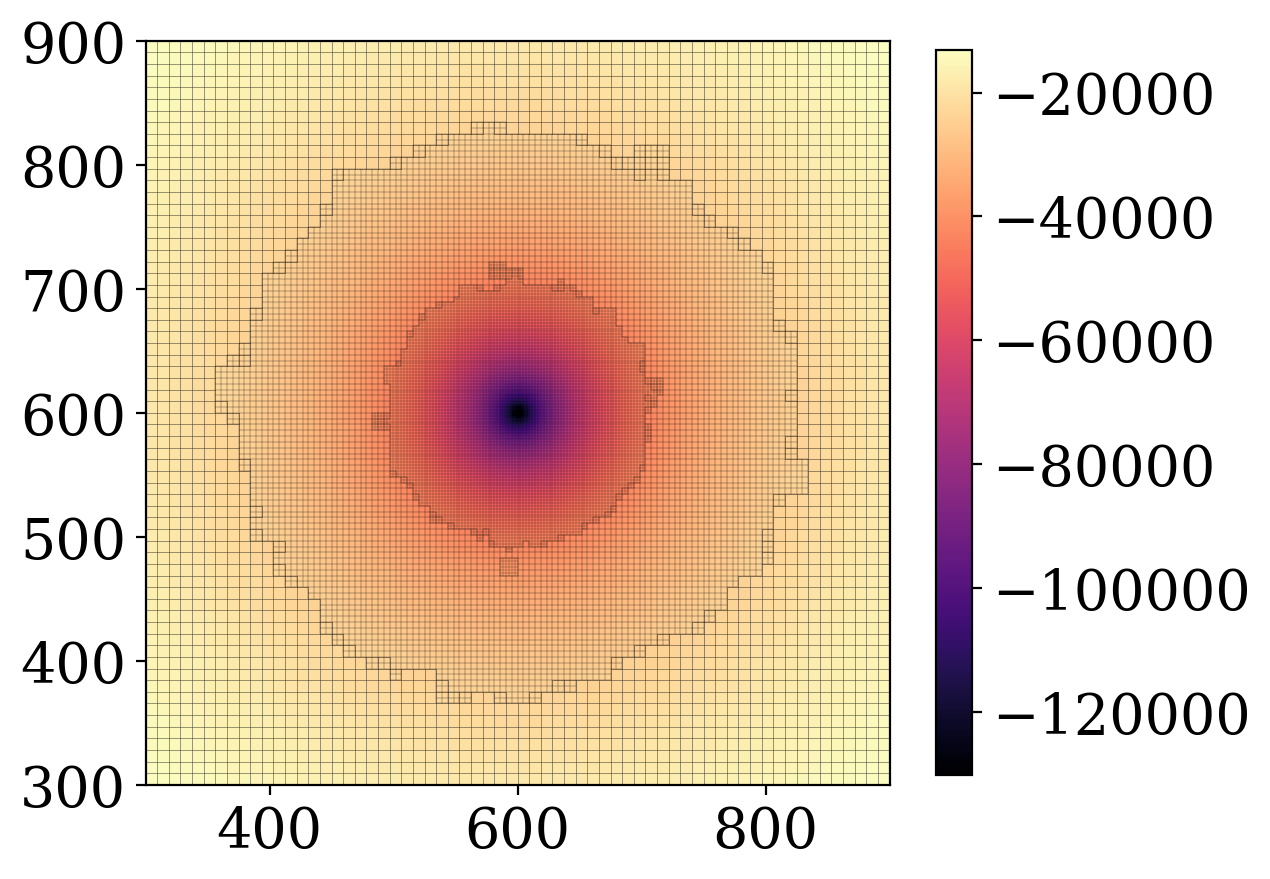

In [7]:
box = [300, 900, 300, 900]

plot(23, 600, grid=True, levels=[8], box=box)
plot(23, 600, grid=True, levels=[7], box=box)
plot(23, 600, grid=True, levels=[6, 7, 8], box=box)

In [ ]:
#mg
'''
     seconds         %    STEP
       0.127       1.0    refine                  
       2.844      21.4    rho                     
       7.502      56.4    poisson                 
       2.797      21.0    particle - kickdrift    
       0.030       0.2    time step               
      13.300     100.0    TOTAL
'''

In [ ]:
#fmm

'''
     seconds         %    STEP
       0.068       0.5    refine                  
       3.020      23.7    rho                     
       7.583      59.6    poisson                 
       0.108       0.9    grav force              
       1.896      14.9    particle - kickdrift    
       0.028       0.2    time step               
       0.017       0.1    recursive call          
      12.721     100.0    TOTAL
'''

In [ ]:
plot(13, 2, False)

In [ ]:
compare(13, 14, 2, True)

In [ ]:
plot(2, 600, False)